## **NAME**: Gavin Abrigo

## **Student ID**: 205260732

⚠️ **Submission Requirement:**  
When submitting, please **export your Jupyter Notebook as a PDF (including all execution outputs)** and submit it, **along with the `.ipynb` source file**. Submissions that do not follow this rule **will receive a grade penalty**.

# Lab 8 Camera and projection

In this lab, we will explore the geometric models of cameras in computer vision. The topics include:

1. Implementing the basic pin-hole camera model and understanding the projection process from 3D space to a 2D image.

2. Learning how to factorize the camera matrix to recover its intrinsic and extrinsic parameters.

3. Applying feature matching and geometric knowledge to estimate the camera's pose from real images.


Required Files:

*   house.p3d


Each blank to be filled is marked with [Grading Point *].

**Complete the implementation below and submit this notebook with your own result by Oct 14 23:59**.



## Problem 1: The Pin-hole Camera Model and 3D Point Projection

**1.1 Theoretical Background**

The pin-hole camera model is a widely used model in computer vision. It describes how a 3D world point **X** is projected onto the camera's 2D image plane to form an image point **x**. This projection can be expressed with a simple matrix equation:

$$\lambda \mathbf{x} = P \mathbf{X}$$

Here, $P$ is a $3 \times 4$ camera matrix, and both $\mathbf{x}$ and $\mathbf{X}$ are expressed in homogeneous coordinates. In this problem, we will create a `Camera` class to implement this projection and observe how camera motion affects the projection.


**1.2 Task: Implement the basic `Camera` Class**

First, create a file named `camera.py`. In this file, you will define a `Camera` class with an initialization method `__init__` and a projection method `project`.

* `__init__(self, P)`: Initializes the object by taking a 3x4 camera matrix `P` and storing it as `self.P`.
* `project(self, X)`: Takes a $4 \times N$ array of homogeneous points `X`, projects them to the image plane via matrix multiplication, and then normalizes them (divides the first two coordinates of each point by its third coordinate). It should return the $3 \times N$ array of projected points `x`.

**Complete the code in the `camera.py` file below:**
<!-- ```python -->

In [46]:
from locale import normalize
from scipy import linalg
import numpy as np

class Camera(object):
    """ Class for representing pin-hole cameras. """
    def __init__(self, P):
        """ Initialize P = K[R|t] camera model. """
        self.P = P
        self.K = None # calibration matrix
        self.R = None # rotation
        self.t = None # translation
        self.c = None # camera center

    def project(self, X):
        """ Project points in X (4*n array) and normalize coordinates. """
        # Project the points using dot product
        x = np.dot(self.P, X)

        # Normalize the projected points
        for i in range(3):
            x[i] /= linalg.norm(x[i]) # Fill in the correct denominator for normalization [Grading Point 1]

        return x
    # Add this function to the Camera class, then define and instantiate the Camera class again

def factor(self):
    """ Factorize the camera matrix into K, R, t. """

    # factor the first 3x3 part of P
    K, R = linalg.rq(self.P[:,:3]) # Perform rq factorization on the correct part of self.P [Grading Point 4]

    # create a diagonal matrix T to ensure the diagonal of K is positive
    T = np.diag(np.sign(np.diag(K)))
    if linalg.det(T) < 0:
        T[1,1] *= -1

    self.K = np.dot(K, T)
    self.R = np.dot(T, R)

    # compute translation t
    self.t = dot(linalg.inv(self.K), self.P[:,3]) # Use the last column of self.P [Grading Point 5]

    return self.K, self.R, self.t



**1.3 Task: Static 3D Point Projection**

Now, use your `Camera` class to project a 3D model. Load the `house.p3d` file, create a simple camera matrix, and plot the resulting projection.

**Complete the code in a new script below:**

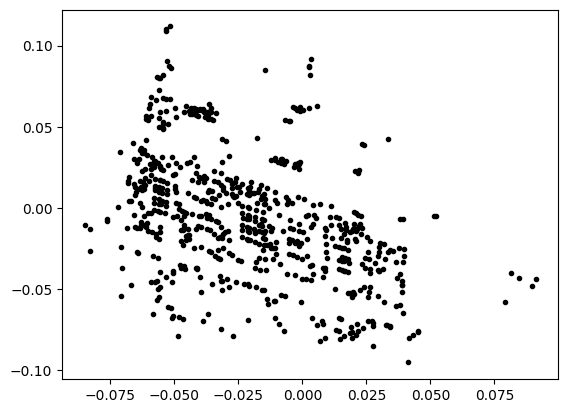

In [47]:
# import Camera
import numpy as np #
from matplotlib.pyplot import figure, plot, show

# Load 3D points from house.p3d and convert to homogeneous coordinates
points = np.loadtxt('./house.p3d').T
points = np.vstack((points, np.ones(points.shape[1])))

# Setup a simple camera matrix
# This camera is at the origin, looking along the negative Z-axis, 10 units from the object.
P = np.hstack((np.eye(3), np.array([[0], [0], [-10]]))) # [Grading Point 2]

# Create a Camera object and project the points
cam = Camera(P)
x = cam.project(points)

# Plot the projected 2D points using matplotlib
figure()
plot(x[0], x[1], 'k.')
show()

**1.4 Task: Simulate Camera Rotation**

To better understand camera motion, we will simulate the effect of rotating the camera around a random axis. First, add a helper function `rotation_matrix(a)` to your `camera.py` file to generate a 3D rotation matrix. Then, write a loop that repeatedly updates the camera matrix with this small rotation and plots the projected points at each step to form a trajectory.

1. Understand rotation_matrix function:

In [48]:
def rotation_matrix(a):
    """ Creates a 3D rotation matrix for rotation around the axis of the vector a. """
    R = np.eye(4)
    R[:3,:3] = linalg.expm([[0,-a[2],a[1]],[a[2],0,-a[0]],[-a[1],a[0],0]])
    return R

2. In your main script, continue from the previous task and complete the following section:

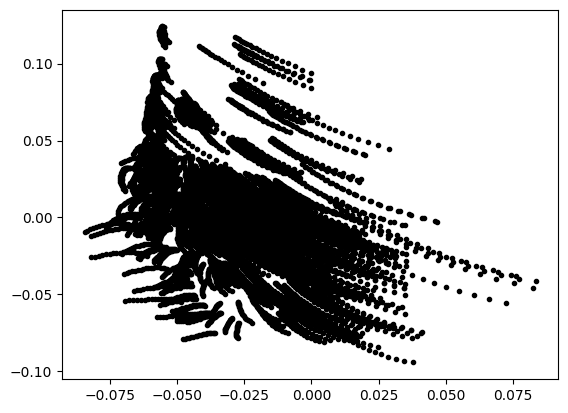

In [49]:
# (Continuing from the previous code)

# Create a small random rotation
r = 0.02 * np.random.rand(3)
rot = rotation_matrix(r)

# Loop to update the camera and plot the trajectory
figure()

for t in range(20):
    # Update the camera matrix by right-multiplying the rotation
    cam.P = np.dot(cam.P, rot) # [Grading Point 3]

    # Project and plot the points
    x = cam.project(points)
    plot(x[0], x[1], 'k.')


show()

## Problem 2: Camera Matrix Factorization and Center Calculation

**2.1 Theoretical Background**

The camera matrix $P$ contains all the geometric information of the camera. It can be factorized into the product of an intrinsic matrix $K$ (describing internal parameters like focal length) and an extrinsic matrix $[R|t]$ (describing the camera's rotation $R$ and translation $t$ in the world frame): $P = K[R|t]$. This factorization is very useful. This problem requires you to implement the factorization of the camera matrix and the calculation of the camera's center.

**2.2 Task: Implement Camera Matrix Factorization**

Add a `factor()` method to your `Camera` class. This method will use RQ-factorization to decompose the left $3 \times 3$ part of the camera matrix into an upper-triangular matrix $K$ and an orthogonal matrix $R$. It also needs to handle sign ambiguity to ensure the diagonal elements of $K$ are positive.

**Complete the `factor()` method in your `camera.py` `Camera` class:**


In [50]:
# Add this function to the Camera class, then define and instantiate the Camera class again

def factor(self):
    """ Factorize the camera matrix into K, R, t. """

    # factor the first 3x3 part of P
    K, R = linalg.rq(self.P[:,:3]) # Perform rq factorization on the correct part of self.P [Grading Point 4]

    # create a diagonal matrix T to ensure the diagonal of K is positive
    T = np.diag(np.sign(np.diag(K)))
    if linalg.det(T) < 0:
        T[1,1] *= -1

    self.K = np.dot(K, T)
    self.R = np.dot(T, R)

    # compute translation t
    self.t = dot(linalg.inv(self.K), self.P[:,3]) # Use the last column of self.P [Grading Point 5]

    return self.K, self.R, self.t



In [51]:
# Add the factor function to the Camera class, then define and instantiate the Camera class again

**2.3 Task: Verify Matrix Factorization**

To verify that your `factor()` method works correctly, write a test script. First, manually define a set of $K, R, t$ parameters to synthesize a camera matrix $P$. Then, initialize a `Camera` object with this $P$, call your `factor()` method, and finally, print and compare the decomposed results with your original definitions.

**Complete the following code in a new script:**

In [52]:
import numpy as np
from Camera import Camera, rotation_matrix

# Define K, R, t
K = np.array([[1000,0,500],[0,1000,300],[0,0,1]])
tmp = rotation_matrix([0,0,1])[:3,:3]
Rt = np.hstack((tmp, np.array([[50],[40],[30]])))

# Compose P and create a Camera object
P = np.dot(K, Rt)
cam = Camera(P) # Instantiate the Camera object [Grading Point 6]

# Call the factor method and print the results
K_est, R_est, t_est = cam.factor() # [Grading Point 7]

print("Original K:\n", K)
print("Estimated K:\n", K_est)
print("\nOriginal Rt:\n", Rt)
print("Estimated Rt:\n", np.hstack((R_est, t_est.reshape(3, 1))))


Original K:
 [[1000    0  500]
 [   0 1000  300]
 [   0    0    1]]
Estimated K:
 [[ 1.00000000e+03  2.27373675e-13  5.00000000e+02]
 [ 0.00000000e+00 -1.00000000e+03  3.00000000e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Original Rt:
 [[ 0.54030231 -0.84147098  0.         50.        ]
 [ 0.84147098  0.54030231  0.         40.        ]
 [ 0.          0.          1.         30.        ]]
Estimated Rt:
 [[  0.54030231  -0.84147098   0.          50.        ]
 [ -0.84147098  -0.54030231   0.         -40.        ]
 [  0.           0.           1.          30.        ]]


## **Problem 3: An Experiment with 3D Rotation and Projection (New)**

**3.1 Theoretical Background**

This problem provides a hands-on way to understand how a camera's orientation in 3D space affects the final 2D image. Instead of calculating the camera's pose from image features, we will do the reverse: we will **define a virtual camera** with a known position and orientation, and use it to project a 3D object onto a real background image.

The core of this task is to see the direct impact of changing the camera's **Rotation Matrix (R)** on the projection of a 3D cube. You will create rotation matrices for different angles and visualize the results, providing an intuitive understanding of the camera's extrinsic parameters.

---

**3.2 Task: Prepare the Projection Tools**

**Objective:** First, we need to set up the basic tools for 3D projection, including a `Camera` class to represent the camera model and a helper function to generate the 3D coordinates of a cube.

**Instructions:** Please run the following code cell. It defines all the necessary classes and functions for the next steps. There will be no visual output from this cell.


In [55]:
# Code for Task 3.2
import numpy as np
from PIL import Image
from matplotlib.pyplot import figure, plot, show, imshow, axis, title
from numpy import sin, cos, pi, array, vstack, ones, dot, hstack


# --- NEW: Function to create a cube with 12 colored edges ---
def create_colored_cube_edges(center, width):
    """
    Creates a cube where each of the 12 edges has a unique color.
    Returns: A list of 12 dictionaries, where each dictionary
             represents an edge and contains its 'points' and 'color'.
    """
    c, w = center, width

    # 1. Define the 8 unique vertices of the cube
    vertices = [
        np.array([c[0]-w, c[1]-w, c[2]-w]), # 0: bottom-left-back
        np.array([c[0]-w, c[1]+w, c[2]-w]), # 1: bottom-right-back
        np.array([c[0]+w, c[1]+w, c[2]-w]), # 2: bottom-right-front
        np.array([c[0]+w, c[1]-w, c[2]-w]), # 3: bottom-left-front
        np.array([c[0]-w, c[1]-w, c[2]+w]), # 4: top-left-back
        np.array([c[0]-w, c[1]+w, c[2]+w]), # 5: top-right-back
        np.array([c[0]+w, c[1]+w, c[2]+w]), # 6: top-right-front
        np.array([c[0]+w, c[1]-w, c[2]+w])  # 7: top-left-front
    ]

    # 2. Define the 12 edges by connecting pairs of vertex indices
    edges_indices = [
        (0, 1), (1, 2), (2, 3), (3, 0),  # Bottom face
        (4, 5), (5, 6), (6, 7), (7, 4),  # Top face
        (0, 4), (1, 5), (2, 6), (3, 7)   # Vertical sides
    ]

    # 3. Define 12 unique colors for the 12 edges
    colors = [
        '#FF0000', '#FF7F00', '#FFFF00', '#00FF00', # Red, Orange, Yellow, Green
        '#0000FF', '#4B0082', '#9400D3', '#FF1493', # Blue, Indigo, Violet, Pink
        '#00FFFF', '#7FFFD4', '#20B2AA', '#A9A9A9'  # Cyan, Aquamarine, Teal, Gray
    ]

    # 4. Bundle the coordinates and colors together
    cube_edges = []
    for i, (v1_idx, v2_idx) in enumerate(edges_indices):
        edge = {
            'points': np.vstack((vertices[v1_idx], vertices[v2_idx])).T,
            'color': colors[i]
        }
        cube_edges.append(edge)

    return cube_edges

# --- make_homog helper function ---
def make_homog(points):
    return np.vstack((points, np.ones((1, points.shape[1]))))

print("Projection tools with colored edges are ready.")

Projection tools with colored edges are ready.


**3.3 Task: Define the Initial Scene**

**Objective:** In this step, we will create our initial scene. This includes loading a background image, defining a 3D cube, and setting up a virtual camera at an initial "0-degree" rotation.

**Instructions:** The following code will define the camera's projection matrix `P` and display the initial projection of the cube, which serves as our baseline for comparison.


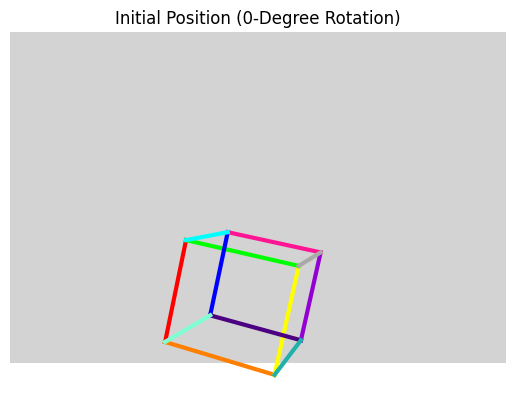

Initial scene is prepared and displayed on a gray background.


In [62]:
# Code for Task 3.3
from scipy.linalg import expm

# --- Camera Intrinsics K ---
def my_calibration(sz):
    row, col = sz
    fx = 2555 * col / 2592
    fy = 2586 * row / 1936
    K = np.array([[fx, 0, 0.5 * col], [0, fy, 0.5 * row], [0, 0, 1]])
    return K

# --- Load image dimensions and define initial camera parameters ---
try:
    # We still need the original image to get the correct dimensions for calibration
    w, h = 768, 512

    # --- NEW: Create a light gray background image ---
    # The RGB value for light gray is (211, 211, 211)
    gray_background = np.ones((h, w, 3), dtype=np.uint8) * 211
    # --- Change complete ---

    K = my_calibration((h, w))

    # Define the camera's initial extrinsic parameters [R_initial|t]
    R_initial = np.dot(expm(np.array([[0,0,0.3],[0,0,0],[-0.3,0,0]])),
                       expm(np.array([[0,-0.2,0],[0.2,0,0],[0,0,0]])))
    t = np.array([[0], [0.1], [0.9]])

    # Create the 3D colored cube object
    colored_box = create_colored_cube_edges([0, 0.1, 0], 0.1)

    # --- Plot the initial view ---
    figure()
    imshow(gray_background) # Use the gray background for plotting
    axis('off')
    title('Initial Position (0-Degree Rotation)')

    # Create the camera for the initial position
    P_0 = np.dot(K, hstack((R_initial, t))) # utilize R_initial and t here [Grading Point 8]
    cam_0 = Camera(P_0)

    # Loop through each edge of the cube to project and plot it
    for edge in colored_box:
        points_3D = edge['points']
        edge_color = edge['color']

        # Project and plot this specific edge
        points_2D = cam_0.project(make_homog(points_3D))
        plot(points_2D[0, :], points_2D[1, :], linewidth=3, color=edge_color)

    show()
    print("Initial scene is prepared and displayed on a gray background.")

except FileNotFoundError:
    print("ERROR: Please make sure 'book_perspective.JPG' is still in the directory to get image dimensions.")

**3.4 Task: Experiment with Different Rotation Angles**

**Objective:** Now it's your turn to experiment. Use the helper function provided below to create rotation matrices for different angles and apply them to the camera to see how the cube's projection changes.

**Instructions:**
1.  The code cell below first defines the `create_rotation_matrix` function.
2.  It then provides a complete example for a **20-degree rotation around the Y-axis**.
3.  **Your task:** Copy the example code block, paste it below the first one in the same cell, and **change the `angle_degrees` and `axis` values** to conduct your own experiments. Try a few different positive and negative angles (e.g., `45`, `-30`) and different axes (`'X'`, `'Y'`, `'Z'`).


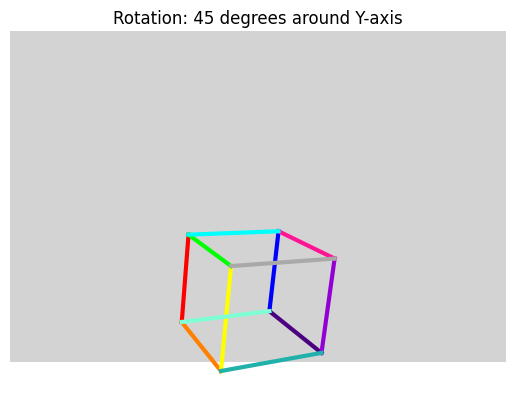

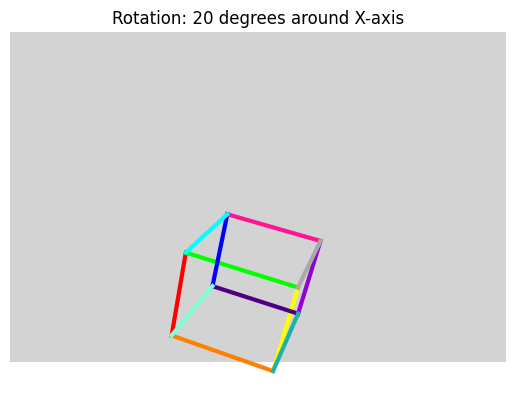

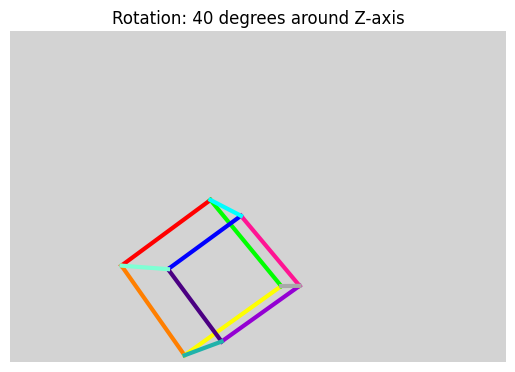

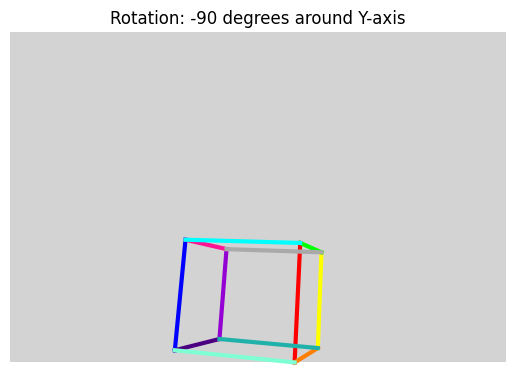

In [74]:
# Code for Task 3.4

def create_rotation_matrix(degrees, axis='Y'):
    """
    Creates a 3x3 rotation matrix from a given angle in degrees
    and a rotation axis ('X', 'Y', or 'Z').
    """
    theta = degrees * pi / 180
    if axis.upper() == 'Y':
        return np.array([[cos(theta), 0, sin(theta)], [0, 1, 0], [-sin(theta), 0, cos(theta)]])
    elif axis.upper() == 'X':
        return np.array([[1, 0, 0], [0, cos(theta), -sin(theta)], [0, sin(theta), cos(theta)]])
    elif axis.upper() == 'Z':
        return np.array([[cos(theta), -sin(theta), 0], [sin(theta), cos(theta), 0], [0, 0, 1]])
    else:
        raise ValueError("Axis must be 'X', 'Y', or 'Z'")

# ================= Example 1: Rotate 45 degrees around Y-axis =================
figure()
imshow(gray_background) # Use the gray background
axis('off')

angle_degrees_1 = 45 # draw this angle's result [Grading Point 9]
axis_1 = 'Y'
title(f'Rotation: {angle_degrees_1} degrees around {axis_1}-axis')

rot_matrix_1 = create_rotation_matrix(angle_degrees_1, axis=axis_1)
R_new_1 = np.dot(rot_matrix_1, R_initial)
P_new_1 = np.dot(K, hstack((R_new_1, t)))
cam_new_1 = Camera(P_new_1)

# Loop through each edge to plot with its color
for edge in colored_box:
    points_2D = cam_new_1.project(make_homog(edge['points']))
    plot(points_2D[0, :], points_2D[1, :], linewidth=3, color=edge['color'])


# ================= Example 2: Rotate 20 degrees around X-axis =================
figure()
imshow(gray_background) # Use the gray background
axis('off')

angle_degrees_2 = 20 # draw this angle's result [Grading Point 10]
axis_2 = 'X'
title(f'Rotation: {angle_degrees_2} degrees around {axis_2}-axis')

rot_matrix_2 = create_rotation_matrix(angle_degrees_2, axis=axis_2)
R_new_2 = np.dot(rot_matrix_2, R_initial)
P_new_2 = np.dot(K, hstack((R_new_2, t)))
cam_new_2 = Camera(P_new_2)

# Loop through each edge to plot with its color
for edge in colored_box:
    points_2D = cam_new_2.project(make_homog(edge['points']))
    plot(points_2D[0, :], points_2D[1, :], linewidth=3, color=edge['color'])


# ====================================================================================
# --- YOUR TURN: Copy an example block above and paste it here to try another angle ---
# ====================================================================================

figure()
imshow(gray_background) # Use the gray background
axis('off')

angle_degrees_3 = 40 # draw this angle's result [Grading Point 10]
axis_3 = 'Z'
title(f'Rotation: {angle_degrees_3} degrees around {axis_3}-axis')

rot_matrix_3 = create_rotation_matrix(angle_degrees_3, axis=axis_3)
R_new_3 = np.dot(rot_matrix_3, R_initial)
P_new_3 = np.dot(K, hstack((R_new_3, t)))
cam_new_3 = Camera(P_new_3)

# Loop through each edge to plot with its color
for edge in colored_box:
    points_2D = cam_new_3.project(make_homog(edge['points']))
    plot(points_2D[0, :], points_2D[1, :], linewidth=3, color=edge['color'])

# ====================================================================================

figure()
imshow(gray_background) # Use the gray background
axis('off')

angle_degrees_4 = -90 # draw this angle's result [Grading Point 10]
axis_4 = 'Y'
title(f'Rotation: {angle_degrees_4} degrees around {axis_4}-axis')

rot_matrix_4 = create_rotation_matrix(angle_degrees_4, axis=axis_4)
R_new_4 = np.dot(rot_matrix_4, R_initial)
P_new_4 = np.dot(K, hstack((R_new_4, t)))
cam_new_4 = Camera(P_new_4)

# Loop through each edge to plot with its color
for edge in colored_box:
    points_2D = cam_new_4.project(make_homog(edge['points']))
    plot(points_2D[0, :], points_2D[1, :], linewidth=3, color=edge['color'])

# Show all the figures you've created
show()